# 🤖 Entrenamiento Baseline - Detección de Toxicidad

**Autor:** [Tu nombre aquí]  
**Fecha:** 2024  
**Objetivo:** Entrenar modelos baseline y registrar resultados en MLFlow

---

## 🎯 ¿Qué vamos a hacer?

Entrenar 2 modelos baseline con nuestros datos procesados y aumentados:

1. **Logistic Regression** → Modelo simple (punto de referencia)
2. **LightGBM** → Modelo principal

Cada miembro del equipo entrena con sus propios datos y registra
los resultados en MLFlow (DagsHub) para comparar.

---

## 📂 Datos que usaremos

| Archivo | Filas | Uso |
|---------|-------|-----|
| `train_augmented.csv` | 1,000 | Entrenar el modelo |
| `val.csv` | 150 | Evaluar durante entrenamiento |
| `test.csv` | 150 | Evaluación final |

---

## 🛠️ Pipeline
train_augmented.csv
↓
TF-IDF Vectorización
↓
┌──────────────────────────┐
│  Logistic Regression     │ → MLFlow
│  LightGBM                │ → MLFlow
└──────────────────────────┘
↓
Comparar resultados en DagsHub

---

## 📊 Métricas que registraremos en MLFlow

- **Accuracy** → % de comentarios clasificados correctamente
- **Precision** → De los que predijo tóxico, ¿cuántos lo eran?
- **Recall** → De los tóxicos reales, ¿cuántos detectó?
- **F1-Score** → Media armónica de Precision y Recall
- **ROC-AUC** → Capacidad de distinguir tóxico vs normal

---

## ⚠️ Overfitting

El proyecto exige que la diferencia entre métricas de
train y test sea **inferior a 5 puntos porcentuales.**
Ejemplo CORRECTO:
Train Accuracy: 92%
Test Accuracy:  89%
Diferencia:      3% ✅ (< 5%)
Ejemplo INCORRECTO:
Train Accuracy: 98%
Test Accuracy:  85%
Diferencia:     13% ❌ (> 5%)

---

In [4]:
# Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import mlflow
import mlflow.sklearn
import mlflow.lightgbm

# Scikit-learn
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)
from sklearn.pipeline import Pipeline

# LightGBM
import lightgbm as lgb

# Configuración
warnings.filterwarnings('ignore')

print("✅ Librerías importadas correctamente")
print(f"\n📦 Versiones:")
print(f"   LightGBM: {lgb.__version__}")
print(f"   MLFlow:   {mlflow.__version__}")

✅ Librerías importadas correctamente

📦 Versiones:
   LightGBM: 4.6.0
   MLFlow:   3.12.0


In [25]:
import dagshub

# Conectar con DagsHub
print("="*80)
print("🔗 CONECTANDO CON DAGSHUB - MLFLOW")
print("="*80)

# Inicializar conexión con DagsHub
dagshub.init(
    repo_owner='gemita284',
    repo_name='Project_9_NLP_Team2',
    mlflow=True
)

# Configurar experimento compartido del equipo
mlflow.set_experiment("youtube_toxic_comments")

print("\n✅ Conexión con DagsHub establecida")
print("✅ Experimento: youtube_toxic_comments")
print("\n🔗 Ver experimentos en:")
print("   https://dagshub.com/gemita284/Project_9_NLP_Team2.mlflow")

🔗 CONECTANDO CON DAGSHUB - MLFLOW


Initialized MLflow to track repo "gemita284/Project_9_NLP_Team2"

Repository gemita284/Project_9_NLP_Team2 initialized!


✅ Conexión con DagsHub establecida
✅ Experimento: youtube_toxic_comments

🔗 Ver experimentos en:
   https://dagshub.com/gemita284/Project_9_NLP_Team2.mlflow


In [6]:
# Cargar los 3 conjuntos de datos
print("="*80)
print("📂 CARGANDO DATASETS")
print("="*80)

df_train = pd.read_csv('../../data/processed/train_augmented.csv')
df_val   = pd.read_csv('../../data/processed/val.csv')
df_test  = pd.read_csv('../../data/processed/test.csv')

# Separar X e y para cada conjunto
X_train = df_train['text_procesado']
y_train = df_train['IsToxic']

X_val = df_val['text_procesado']
y_val = df_val['IsToxic']

X_test = df_test['text_procesado']
y_test = df_test['IsToxic']

# Verificar
print(f"\n🟢 TRAIN:")
print(f"   Total: {len(X_train):,} comentarios")
print(f"   Normal: {sum(y_train==False):,} ({sum(y_train==False)/len(y_train)*100:.1f}%)")
print(f"   Tóxico: {sum(y_train==True):,} ({sum(y_train==True)/len(y_train)*100:.1f}%)")

print(f"\n🟡 VALIDATION:")
print(f"   Total: {len(X_val):,} comentarios")
print(f"   Normal: {sum(y_val==False):,} ({sum(y_val==False)/len(y_val)*100:.1f}%)")
print(f"   Tóxico: {sum(y_val==True):,} ({sum(y_val==True)/len(y_val)*100:.1f}%)")

print(f"\n🔴 TEST:")
print(f"   Total: {len(X_test):,} comentarios")
print(f"   Normal: {sum(y_test==False):,} ({sum(y_test==False)/len(y_test)*100:.1f}%)")
print(f"   Tóxico: {sum(y_test==True):,} ({sum(y_test==True)/len(y_test)*100:.1f}%)")

print(f"\n✅ Datos cargados correctamente")

📂 CARGANDO DATASETS

🟢 TRAIN:
   Total: 1,000 comentarios
   Normal: 500 (50.0%)
   Tóxico: 500 (50.0%)

🟡 VALIDATION:
   Total: 150 comentarios
   Normal: 80 (53.3%)
   Tóxico: 70 (46.7%)

🔴 TEST:
   Total: 150 comentarios
   Normal: 81 (54.0%)
   Tóxico: 69 (46.0%)

✅ Datos cargados correctamente


In [7]:
# Vectorización TF-IDF
print("="*80)
print("🔢 VECTORIZACIÓN TF-IDF")
print("="*80)

# Crear vectorizador
vectorizer = TfidfVectorizer(
    max_features=3000,  # Top 3,000 palabras
    ngram_range=(1, 2),  # Unigrams y bigrams
    min_df=3,            # Mínimo 3 apariciones
    max_df=0.85,         # Máximo en 85% de documentos
    sublinear_tf=True    # Suavizar frecuencias
)

# SOLO fit en TRAIN
print("\n⏳ Ajustando vectorizador en train...")
X_train_vec = vectorizer.fit_transform(X_train)

# Solo transform en val y test
print("⏳ Transformando val y test...")
X_val_vec   = vectorizer.transform(X_val)
X_test_vec  = vectorizer.transform(X_test)

print(f"\n✅ Vectorización completada")
print(f"\n📊 Dimensiones:")
print(f"   X_train: {X_train_vec.shape} (comentarios × features)")
print(f"   X_val:   {X_val_vec.shape}")
print(f"   X_test:  {X_test_vec.shape}")
print(f"\n📚 Vocabulario aprendido: {len(vectorizer.vocabulary_):,} palabras")
print(f"\n🔎 Ejemplo de features:")
print(f"   {list(vectorizer.vocabulary_.keys())[:10]}")

🔢 VECTORIZACIÓN TF-IDF

⏳ Ajustando vectorizador en train...
⏳ Transformando val y test...

✅ Vectorización completada

📊 Dimensiones:
   X_train: (1000, 1492) (comentarios × features)
   X_val:   (150, 1492)
   X_test:  (150, 1492)

📚 Vocabulario aprendido: 1,492 palabras

🔎 Ejemplo de features:
   ['majority', 'people', 'ferguson', 'african', 'american', 'elected', 'official', 'mayor', 'city', 'council']


In [21]:
# BASELINE 1: ENTRENAR LOGISTIC REGRESSION
print("="*80)
print("📊 BASELINE 1: LOGISTIC REGRESSION - ENTRENAMIENTO")
print("="*80)

# Crear modelo
lr_model = LogisticRegression(
    C=0.1,                  # Regularización fuerte (default es 1.0)
    max_iter=1000,
    class_weight='balanced',
    solver='saga',          # Mejor para datasets grandes
    penalty='l2',           # Regularización L2
    random_state=42
)

# Entrenar
print("\n⏳ Entrenando modelo...")
lr_model.fit(X_train_vec, y_train)
print("✅ Modelo entrenado correctamente")

# Predicciones en train y test
y_pred_train = lr_model.predict(X_train_vec)
y_pred_test  = lr_model.predict(X_test_vec)
y_proba_test = lr_model.predict_proba(X_test_vec)[:, 1]

print(f"\n✅ Predicciones generadas:")
print(f"   y_pred_train: {len(y_pred_train)} predicciones")
print(f"   y_pred_test:  {len(y_pred_test)} predicciones")
print(f"   y_proba_test: {len(y_proba_test)} probabilidades")

📊 BASELINE 1: LOGISTIC REGRESSION - ENTRENAMIENTO

⏳ Entrenando modelo...
✅ Modelo entrenado correctamente

✅ Predicciones generadas:
   y_pred_train: 1000 predicciones
   y_pred_test:  150 predicciones
   y_proba_test: 150 probabilidades


📊 BASELINE 1: MÉTRICAS Y MATRIZ DE CONFUSIÓN

📊 MÉTRICAS:
  Accuracy Train:   89.8%
  Accuracy Test:    73.3%
  Overfitting Acc:  16.5%
  F1 Train:         89.7%
  F1 Test:          68.3%
  Overfitting F1:   21.4%
  Precision Test:   75.4%
  Recall Test:      62.3%
  ROC-AUC Test:     80.7%

⚠️ Overfitting ALTO (> 5%)

📋 REPORTE COMPLETO:
              precision    recall  f1-score   support

      Normal       0.72      0.83      0.77        81
      Tóxico       0.75      0.62      0.68        69

    accuracy                           0.73       150
   macro avg       0.74      0.73      0.73       150
weighted avg       0.74      0.73      0.73       150


📊 MATRIZ DE CONFUSIÓN


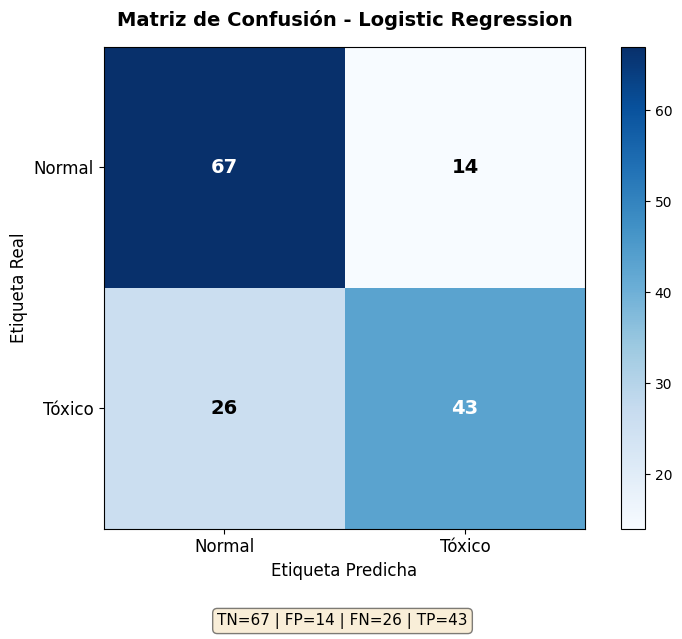


📊 ANÁLISIS:
   ✅ TN: 67 normales bien clasificados
   ✅ TP: 43 tóxicos bien clasificados
   ❌ FP: 14 normales marcados como tóxicos
   ❌ FN: 26 tóxicos que NO detectó

✅ Matriz guardada en: ../../reports/V_02/confusion_matrix_LogisticRegression.png


In [22]:
# BASELINE 1: MÉTRICAS + MATRIZ DE CONFUSIÓN

import os

print("="*80)
print("📊 BASELINE 1: MÉTRICAS Y MATRIZ DE CONFUSIÓN")
print("="*80)

avg_method = 'binary'

# Calcular métricas
acc_train = accuracy_score(y_train, y_pred_train)
acc_test  = accuracy_score(y_test, y_pred_test)
f1_train  = f1_score(y_train, y_pred_train, average=avg_method)
f1_test   = f1_score(y_test, y_pred_test, average=avg_method)

# Mostrar métricas
print(f"\n📊 MÉTRICAS:")
print(f"{'='*40}")
print(f"  Accuracy Train:   {acc_train*100:.1f}%")
print(f"  Accuracy Test:    {acc_test*100:.1f}%")
print(f"  Overfitting Acc:  {(acc_train-acc_test)*100:.1f}%")
print(f"{'='*40}")
print(f"  F1 Train:         {f1_train*100:.1f}%")
print(f"  F1 Test:          {f1_test*100:.1f}%")
print(f"  Overfitting F1:   {(f1_train-f1_test)*100:.1f}%")
print(f"{'='*40}")
print(f"  Precision Test:   {precision_score(y_test, y_pred_test, average=avg_method)*100:.1f}%")
print(f"  Recall Test:      {recall_score(y_test, y_pred_test, average=avg_method)*100:.1f}%")
print(f"  ROC-AUC Test:     {roc_auc_score(y_test, y_proba_test)*100:.1f}%")

# Verificar overfitting
print(f"\n{'='*40}")
if (acc_train - acc_test) < 0.05:
    print(f"✅ Overfitting CONTROLADO (< 5%)")
else:
    print(f"⚠️ Overfitting ALTO (> 5%)")

# Reporte completo
print(f"\n📋 REPORTE COMPLETO:")
print(classification_report(y_test, y_pred_test,
      target_names=['Normal', 'Tóxico']))

# Matriz de confusión
print(f"\n{'='*80}")
print(f"📊 MATRIZ DE CONFUSIÓN")
print(f"{'='*80}")

cm = confusion_matrix(y_test, y_pred_test)
tn, fp, fn, tp = cm.ravel()

# Crear figura
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.colorbar(im)

# Etiquetas
clases = ['Normal', 'Tóxico']
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(clases, fontsize=12)
ax.set_yticklabels(clases, fontsize=12)

# Números en cada celda
thresh = cm.max() / 2
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(cm[i, j], 'd'),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black",
                fontsize=14, fontweight='bold')

# Títulos
ax.set_title('Matriz de Confusión - Logistic Regression',
             fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Etiqueta Real', fontsize=12)
ax.set_xlabel('Etiqueta Predicha', fontsize=12)

# Métricas debajo
plt.figtext(0.5, -0.05,
            f'TN={tn} | FP={fp} | FN={fn} | TP={tp}',
            ha='center', fontsize=11,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()

# Guardar imagen
os.makedirs('../../reports/V_02', exist_ok=True)
ruta_cm_lr = '../../reports/V_02/confusion_matrix_LogisticRegression.png'
plt.savefig(ruta_cm_lr, dpi=150, bbox_inches='tight')
plt.show()

# Análisis de la matriz
print(f"\n📊 ANÁLISIS:")
print(f"   ✅ TN: {tn} normales bien clasificados")
print(f"   ✅ TP: {tp} tóxicos bien clasificados")
print(f"   ❌ FP: {fp} normales marcados como tóxicos")
print(f"   ❌ FN: {fn} tóxicos que NO detectó")
print(f"\n✅ Matriz guardada en: {ruta_cm_lr}")

In [ ]:
# REGISTRAR LOGISTIC REGRESSION EN MLFLOW
print("="*80)
print("📡 REGISTRANDO LOGISTIC REGRESSION EN MLFLOW")
print("="*80)

with mlflow.start_run(run_name="LogisticRegression_baseline"):

    # Parámetros del modelo
    mlflow.log_param("modelo", "LogisticRegression")
    mlflow.log_param("C", 0.1)
    mlflow.log_param("penalty", "l2")
    mlflow.log_param("solver", "saga")
    mlflow.log_param("max_iter", 1000)
    mlflow.log_param("class_weight", "balanced")

    # Parámetros del vectorizador
    mlflow.log_param("vectorizer", "TF-IDF")
    mlflow.log_param("max_features", 3000)
    mlflow.log_param("ngram_range", "(1,2)")
    mlflow.log_param("min_df", 3)
    mlflow.log_param("max_df", 0.85)

    # Métricas estandarizadas del equipo
    mlflow.log_metrics({
        "accuracy_train":  acc_train,
        "accuracy_test":   acc_test,
        "f1_train":        f1_train,
        "f1_test":         f1_test,
        "precision_test":  precision_score(y_test, y_pred_test, average=avg_method),
        "recall_test":     recall_score(y_test, y_pred_test, average=avg_method),
        "roc_auc_test":    roc_auc_score(y_test, y_proba_test),
        "overfitting_acc": acc_train - acc_test,
        "overfitting_f1":  f1_train - f1_test
    })

    # Tags
    mlflow.set_tag("developer", "Gema")
    mlflow.set_tag("model_type", "baseline")
    mlflow.set_tag("vectorizer", "TF-IDF")

    # Subir matriz de confusión como artefacto
    mlflow.log_artifact(ruta_cm_lr)

    # Guardar modelo
    mlflow.sklearn.log_model(lr_model, "logistic_regression_model")

    print(f"\n✅ Métricas registradas")
    print(f"✅ Matriz de confusión subida como artefacto")
    print(f"✅ Modelo guardado")
    print(f"\n🔗 Ver en DagsHub:")
    print(f"   https://dagshub.com/gemita284/Project_9_NLP_Team2.mlflow")

📡 REGISTRANDO LOGISTIC REGRESSION EN MLFLOW


2026/05/12 13:17:24 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/12 13:17:45 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/12 13:17:50 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


---

## 🤖 Baseline 2: LightGBM

**¿Por qué LightGBM?**
- Modelo principal del proyecto
- Más potente que Logistic Regression
- Maneja relaciones no lineales en texto
- Rápido y eficiente

**Parámetros baseline (sin optimizar):**
- `n_estimators=100` → 100 árboles
- `learning_rate=0.1` → Tasa de aprendizaje
- `num_leaves=31` → Hojas por árbol
- `class_weight='balanced'` → Maneja desbalance

**Esperamos:**
- Menos overfitting que Logistic Regression
- Mejor accuracy en test
- Overfitting < 5%

In [17]:
# BASELINE 2: ENTRENAR LIGHTGBM
print("="*80)
print("🤖 BASELINE 2: LIGHTGBM - ENTRENAMIENTO")
print("="*80)

# Crear modelo
lgbm_model = lgb.LGBMClassifier(
    n_estimators=50,         # Bajamos de 100 a 50
    learning_rate=0.05,      # Bajamos de 0.1 a 0.05
    num_leaves=15,           # Bajamos de 31 a 15
    max_depth=5,             # Limitamos profundidad
    min_child_samples=20,    # Mínimo 20 muestras por hoja
    class_weight='balanced',
    random_state=42,
    verbose=-1
)
# Entrenar
print("\n⏳ Entrenando LightGBM...")
lgbm_model.fit(
    X_train_vec, y_train,
    eval_set=[(X_val_vec, y_val)],  # Validar durante entrenamiento
)
print("✅ Modelo entrenado correctamente")

# Predicciones
y_pred_train_lgbm = lgbm_model.predict(X_train_vec)
y_pred_test_lgbm  = lgbm_model.predict(X_test_vec)
y_proba_test_lgbm = lgbm_model.predict_proba(X_test_vec)[:, 1]

print(f"\n✅ Predicciones generadas:")
print(f"   y_pred_train: {len(y_pred_train_lgbm)} predicciones")
print(f"   y_pred_test:  {len(y_pred_test_lgbm)} predicciones")
print(f"   y_proba_test: {len(y_proba_test_lgbm)} probabilidades")

🤖 BASELINE 2: LIGHTGBM - ENTRENAMIENTO

⏳ Entrenando LightGBM...
✅ Modelo entrenado correctamente

✅ Predicciones generadas:
   y_pred_train: 1000 predicciones
   y_pred_test:  150 predicciones
   y_proba_test: 150 probabilidades


📊 BASELINE 2: MÉTRICAS Y MATRIZ DE CONFUSIÓN LIGHTGBM

📊 MÉTRICAS:
  Accuracy Train:   74.3%
  Accuracy Test:    72.0%
  Overfitting Acc:  2.3%
  F1 Train:         69.1%
  F1 Test:          61.8%
  Overfitting F1:   7.3%
  Precision Test:   82.9%
  Recall Test:      49.3%
  ROC-AUC Test:     73.9%

✅ Overfitting CONTROLADO (< 5%)

📋 REPORTE COMPLETO:
              precision    recall  f1-score   support

      Normal       0.68      0.91      0.78        81
      Tóxico       0.83      0.49      0.62        69

    accuracy                           0.72       150
   macro avg       0.75      0.70      0.70       150
weighted avg       0.75      0.72      0.70       150


📊 MATRIZ DE CONFUSIÓN - LIGHTGBM


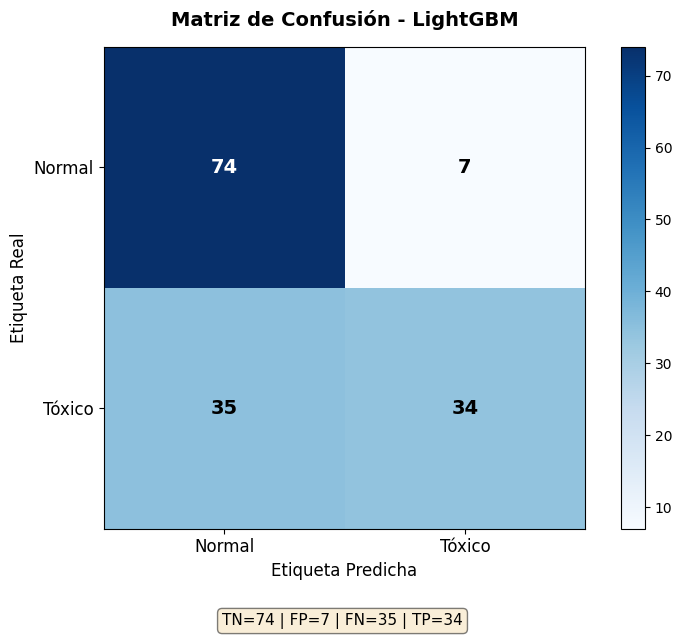


📊 ANÁLISIS:
   ✅ TN: 74 normales bien clasificados
   ✅ TP: 34 tóxicos bien clasificados
   ❌ FP: 7 normales marcados como tóxicos
   ❌ FN: 35 tóxicos que NO detectó

✅ Matriz guardada en: ../../reports/V_02/confusion_matrix_LightGBM.png


In [18]:
# BASELINE 2: MÉTRICAS + MATRIZ DE CONFUSIÓN LIGHTGBM
print("="*80)
print("📊 BASELINE 2: MÉTRICAS Y MATRIZ DE CONFUSIÓN LIGHTGBM")
print("="*80)

# Definir método de promedio
avg_method = 'binary'

# Calcular métricas
acc_train_lgbm = accuracy_score(y_train, y_pred_train_lgbm)
acc_test_lgbm  = accuracy_score(y_test, y_pred_test_lgbm)
f1_train_lgbm  = f1_score(y_train, y_pred_train_lgbm, average=avg_method)
f1_test_lgbm   = f1_score(y_test, y_pred_test_lgbm, average=avg_method)

# Mostrar métricas
print(f"\n📊 MÉTRICAS:")
print(f"{'='*40}")
print(f"  Accuracy Train:   {acc_train_lgbm*100:.1f}%")
print(f"  Accuracy Test:    {acc_test_lgbm*100:.1f}%")
print(f"  Overfitting Acc:  {(acc_train_lgbm-acc_test_lgbm)*100:.1f}%")
print(f"{'='*40}")
print(f"  F1 Train:         {f1_train_lgbm*100:.1f}%")
print(f"  F1 Test:          {f1_test_lgbm*100:.1f}%")
print(f"  Overfitting F1:   {(f1_train_lgbm-f1_test_lgbm)*100:.1f}%")
print(f"{'='*40}")
print(f"  Precision Test:   {precision_score(y_test, y_pred_test_lgbm, average=avg_method)*100:.1f}%")
print(f"  Recall Test:      {recall_score(y_test, y_pred_test_lgbm, average=avg_method)*100:.1f}%")
print(f"  ROC-AUC Test:     {roc_auc_score(y_test, y_proba_test_lgbm)*100:.1f}%")

# Verificar overfitting
print(f"\n{'='*40}")
if (acc_train_lgbm - acc_test_lgbm) < 0.05:
    print(f"✅ Overfitting CONTROLADO (< 5%)")
else:
    print(f"⚠️ Overfitting ALTO (> 5%)")

# Reporte completo
print(f"\n📋 REPORTE COMPLETO:")
print(classification_report(y_test, y_pred_test_lgbm,
      target_names=['Normal', 'Tóxico']))

# Matriz de confusión
print(f"\n{'='*80}")
print(f"📊 MATRIZ DE CONFUSIÓN - LIGHTGBM")
print(f"{'='*80}")

cm_lgbm = confusion_matrix(y_test, y_pred_test_lgbm)
tn, fp, fn, tp = cm_lgbm.ravel()

# Crear figura
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm_lgbm, interpolation='nearest', cmap=plt.cm.Blues)
plt.colorbar(im)

# Etiquetas
clases = ['Normal', 'Tóxico']
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(clases, fontsize=12)
ax.set_yticklabels(clases, fontsize=12)

# Números en cada celda
thresh = cm_lgbm.max() / 2
for i in range(cm_lgbm.shape[0]):
    for j in range(cm_lgbm.shape[1]):
        ax.text(j, i, format(cm_lgbm[i, j], 'd'),
                ha="center", va="center",
                color="white" if cm_lgbm[i, j] > thresh else "black",
                fontsize=14, fontweight='bold')

# Títulos
ax.set_title('Matriz de Confusión - LightGBM',
             fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Etiqueta Real', fontsize=12)
ax.set_xlabel('Etiqueta Predicha', fontsize=12)

# Métricas debajo
plt.figtext(0.5, -0.05,
            f'TN={tn} | FP={fp} | FN={fn} | TP={tp}',
            ha='center', fontsize=11,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()

# Guardar imagen
ruta_cm_lgbm = '../../reports/V_02/confusion_matrix_LightGBM.png'
plt.savefig(ruta_cm_lgbm, dpi=150, bbox_inches='tight')
plt.show()

# Análisis
print(f"\n📊 ANÁLISIS:")
print(f"   ✅ TN: {tn} normales bien clasificados")
print(f"   ✅ TP: {tp} tóxicos bien clasificados")
print(f"   ❌ FP: {fp} normales marcados como tóxicos")
print(f"   ❌ FN: {fn} tóxicos que NO detectó")
print(f"\n✅ Matriz guardada en: {ruta_cm_lgbm}")

In [26]:
# REGISTRAR LIGHTGBM EN MLFLOW
print("="*80)
print("📡 REGISTRANDO LIGHTGBM EN MLFLOW")
print("="*80)

with mlflow.start_run(run_name="LightGBM_baseline"):

    # Parámetros del modelo
    mlflow.log_param("modelo", "LightGBM")
    mlflow.log_param("n_estimators", 50)
    mlflow.log_param("learning_rate", 0.05)
    mlflow.log_param("num_leaves", 15)
    mlflow.log_param("max_depth", 5)
    mlflow.log_param("min_child_samples", 20)
    mlflow.log_param("class_weight", "balanced")

    # Parámetros del vectorizador
    mlflow.log_param("vectorizer", "TF-IDF")
    mlflow.log_param("max_features", 3000)
    mlflow.log_param("ngram_range", "(1,2)")
    mlflow.log_param("min_df", 3)
    mlflow.log_param("max_df", 0.85)

    # Métricas estandarizadas del equipo
    mlflow.log_metrics({
        "accuracy_train":  acc_train_lgbm,
        "accuracy_test":   acc_test_lgbm,
        "f1_train":        f1_train_lgbm,
        "f1_test":         f1_test_lgbm,
        "precision_test":  precision_score(y_test, y_pred_test_lgbm, average=avg_method),
        "recall_test":     recall_score(y_test, y_pred_test_lgbm, average=avg_method),
        "roc_auc_test":    roc_auc_score(y_test, y_proba_test_lgbm),
        "overfitting_acc": acc_train_lgbm - acc_test_lgbm,
        "overfitting_f1":  f1_train_lgbm - f1_test_lgbm
    })

    # Tags
    mlflow.set_tag("developer", "Gema")
    mlflow.set_tag("model_type", "baseline")
    mlflow.set_tag("vectorizer", "TF-IDF")

    # Subir matriz de confusión como artefacto
    mlflow.log_artifact(ruta_cm_lgbm)

    # Guardar modelo
    mlflow.lightgbm.log_model(lgbm_model, "lightgbm_model")

    print(f"\n✅ Métricas registradas")
    print(f"✅ Matriz de confusión subida como artefacto")
    print(f"✅ Modelo guardado")
    print(f"\n🔗 Ver en DagsHub:")
    print(f"   https://dagshub.com/gemita284/Project_9_NLP_Team2.mlflow")

📡 REGISTRANDO LIGHTGBM EN MLFLOW


2026/05/12 15:02:37 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/12 15:02:49 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/12 15:02:57 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.



✅ Métricas registradas
✅ Matriz de confusión subida como artefacto
✅ Modelo guardado

🔗 Ver en DagsHub:
   https://dagshub.com/gemita284/Project_9_NLP_Team2.mlflow
🏃 View run LightGBM_baseline at: https://dagshub.com/gemita284/Project_9_NLP_Team2.mlflow/#/experiments/0/runs/e0d984eea2a74e6699905a52904bae19
🧪 View experiment at: https://dagshub.com/gemita284/Project_9_NLP_Team2.mlflow/#/experiments/0


In [24]:
# Ejecuta esto en una nueva celda
mlflow.end_run()
print("✅ Run cerrado correctamente")

✅ Run cerrado correctamente
